In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import stft, istft
import scipy.ndimage as ndimage

# 1. Cargar el audio
samplerate, data = wavfile.read('Audio1.wav')
if len(data.shape) > 1:
    data = data[:, 0]

# 2. Normalización de datos (evita errores matemáticos por números muy grandes)
data_norm = data / np.max(np.abs(data))

# 3. Creación del vector de tiempo para nuestras gráficas finales
t = np.arange(0, len(data_norm)) / samplerate

print(f"Audio preparado. Frecuencia: {samplerate} Hz | Duración: {t[-1]:.2f} segundos")

Audio preparado. Frecuencia: 48000 Hz | Duración: 12.48 segundos


In [8]:
# 1. Aplicar la Transformada Rápida de Fourier por ventanas (STFT)
f, time_stft, Zxx = stft(data_norm, fs=samplerate, nperseg=2048)

# Separar el volumen (magnitud) y el retraso de la onda (fase)
magnitud = np.abs(Zxx)
fase = np.angle(Zxx)

# 2. Capturar la "huella dactilar" del ruido ambiental (usando el primer medio segundo)
tiempo_ruido_segundos = 0.5 
muestras_ruido = int(tiempo_ruido_segundos / (time_stft[1] - time_stft[0]))
perfil_ruido = np.mean(magnitud[:, :muestras_ruido], axis=1, keepdims=True)

print("Matriz de frecuencias generada y perfil de ruido capturado con éxito.")

Matriz de frecuencias generada y perfil de ruido capturado con éxito.


In [9]:
# 1. Calibración del filtro
AGRESIVIDAD = 3.5 
ruido_amplificado = perfil_ruido * AGRESIVIDAD

# 2. Cálculo de Relación Señal/Ruido (SNR) y creación de la Máscara
snr = magnitud / (ruido_amplificado + 1e-10)
mascara = 1.0 - (1.0 / snr)

# 3. Forzar un piso de ruido casi nulo
mascara[mascara < 0.001] = 0.001 

# 4. Suavizado matemático (elimina las "burbujas" o artefactos robóticos)
mascara_suavizada = ndimage.gaussian_filter(mascara, sigma=(1, 2))
magnitud_limpia = magnitud * mascara_suavizada

print("Máscara de atenuación calculada y aplicada a las frecuencias.")

Máscara de atenuación calculada y aplicada a las frecuencias.


/var/folders/jd/bjhpr0zj7nqbr4sfnbqjr33m0000gn/T/ipykernel_99691/3586736367.py:7: RuntimeWarning: divide by zero encountered in divide
  mascara = 1.0 - (1.0 / snr)


In [10]:
import os

# 1. Unir la magnitud limpia con la fase original
Zxx_limpio = magnitud_limpia * np.exp(1j * fase)

# 2. Transformada Inversa (Regresamos al dominio del tiempo)
_, audio_recuperado = istft(Zxx_limpio, fs=samplerate)

# 3. Guardar el archivo usando un nombre incremental sin sobrescribir
base_nombre = 'Audio'
extension = '.wav'
contador = 1

while os.path.exists(f'{base_nombre}{contador}{extension}'):
    contador += 1

nombre_archivo = f'{base_nombre}{contador}{extension}'
audio_final = np.int16(audio_recuperado * 32767 / np.max(np.abs(audio_recuperado)))
wavfile.write(nombre_archivo, samplerate, audio_final)

print(f"¡Audio reconstruido! Se ha guardado como '{nombre_archivo}'")

¡Audio reconstruido! Se ha guardado como 'Audio2.wav'


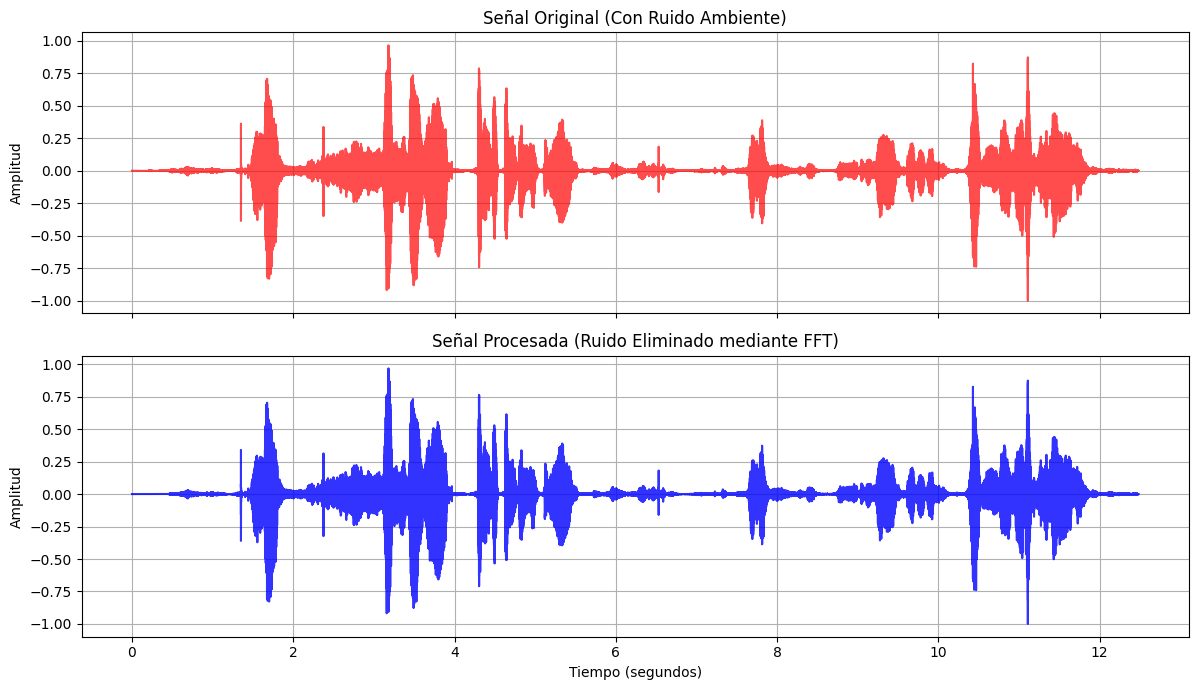

In [12]:
fig, axs = plt.subplots(2, 1, figsize=(12, 7), sharex=True, sharey=True)

# Gráfico 1: Audio original con ruido
axs[0].plot(t, data_norm, color='red', alpha=0.7)
axs[0].set_title('Señal Original (Con Ruido Ambiente)')
axs[0].set_ylabel('Amplitud')
axs[0].grid(True)

# Gráfico 2: Audio procesado y limpio
# Normalizamos el audio recuperado para que visualmente tengan la misma escala
audio_recuperado_norm = audio_recuperado / np.max(np.abs(audio_recuperado))
axs[1].plot(t, audio_recuperado_norm, color='blue', alpha=0.8)
axs[1].set_title('Señal Procesada (Ruido Eliminado mediante FFT)')
axs[1].set_xlabel('Tiempo (segundos)')
axs[1].set_ylabel('Amplitud')
axs[1].grid(True)

plt.tight_layout()
plt.show()